In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [5]:
nav_df = pd.read_csv("../data/processed/02_nav_history_clean.csv")

nav_df["date"] = pd.to_datetime(nav_df["date"])

print(nav_df.head())
print(nav_df.shape)

   amfi_code       date       nav
0     100016 2022-01-03  520.4608
1     100016 2022-01-04  515.0971
2     100016 2022-01-05  521.7239
3     100016 2022-01-06  515.7880
4     100016 2022-01-07  515.1639
(46000, 3)


In [6]:
nav_df = nav_df.sort_values(["amfi_code", "date"])

nav_df["daily_return"] = nav_df.groupby("amfi_code")["nav"].pct_change()

print(nav_df.head(10))

   amfi_code       date       nav  daily_return
0     100016 2022-01-03  520.4608           NaN
1     100016 2022-01-04  515.0971     -0.010306
2     100016 2022-01-05  521.7239      0.012865
3     100016 2022-01-06  515.7880     -0.011377
4     100016 2022-01-07  515.1639     -0.001210
5     100016 2022-01-10  510.7136     -0.008639
6     100016 2022-01-11  513.5542      0.005562
7     100016 2022-01-12  512.3195     -0.002404
8     100016 2022-01-13  510.2445     -0.004050
9     100016 2022-01-14  514.3636      0.008073


In [7]:
print(nav_df["daily_return"].describe())

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


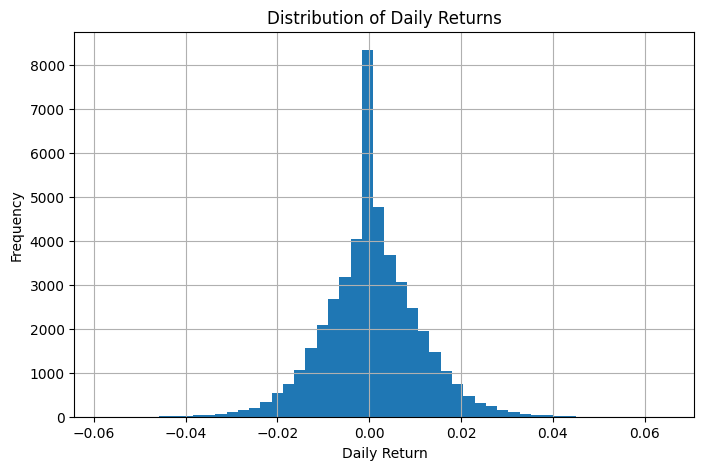

In [8]:
plt.figure(figsize=(8,5))

nav_df["daily_return"].hist(bins=50)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()


## Daily Return Analysis

Daily returns were calculated using percentage change in NAV for each mutual fund.

Observations:
- Most returns are concentrated around 0%.
- Small positive and negative returns occur frequently.
- Extreme gains and losses are rare.
- The distribution appears approximately normal, indicating a realistic return pattern.

Conclusion:
The daily return distribution looks reasonable and suitable for further performance analysis.

In [9]:
cagr_df = nav_df.groupby("amfi_code").agg(
    start_nav=("nav", "first"),
    end_nav=("nav", "last")
).reset_index()

years = 4

cagr_df["cagr"] = (
    (cagr_df["end_nav"] / cagr_df["start_nav"]) ** (1 / years) - 1
)

cagr_df = cagr_df.sort_values("cagr", ascending=False)

print(cagr_df.head(10))

    amfi_code  start_nav   end_nav      cagr
25     120505   135.8720  473.7640  0.366495
21     119598    89.8738  309.2050  0.361925
39     149324    81.6814  279.7511  0.360386
36     148569    28.8620   97.7435  0.356564
34     148567    70.2514  230.2708  0.345538
30     120843    49.9131  163.2397  0.344785
2      100033   107.3758  342.0072  0.335925
38     149323    78.4622  245.3651  0.329805
16     119094    68.3023  203.8581  0.314387
19     119551    54.3856  149.3216  0.287240


## CAGR Analysis

CAGR (Compound Annual Growth Rate) was calculated for each mutual fund using the first and last NAV values over the available period.

Observations:
- CAGR helps compare long-term performance across funds.
- Higher CAGR indicates stronger annualized growth.
- The top-ranked funds achieved CAGR values above 30%.

Conclusion:
Several funds demonstrated strong long-term growth performance, making them potential candidates for further risk-adjusted evaluation.

In [10]:
risk_free_rate = 0.065

sharpe_df = nav_df.groupby("amfi_code")["daily_return"].agg(
    mean_return="mean",
    volatility="std"
).reset_index()

sharpe_df["annual_return"] = sharpe_df["mean_return"] * 252

sharpe_df["annual_volatility"] = sharpe_df["volatility"] * np.sqrt(252)

sharpe_df["sharpe_ratio"] = (
    (sharpe_df["annual_return"] - risk_free_rate)
    / sharpe_df["annual_volatility"]
)

sharpe_df = sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
)

print(sharpe_df.head(10))

    amfi_code  mean_return  volatility  annual_return  annual_volatility  \
34     148567     0.001074    0.008941       0.270566           0.141937   
30     120843     0.001082    0.010008       0.272602           0.158870   
36     148569     0.001124    0.011134       0.283262           0.176740   
19     119551     0.000917    0.008656       0.231033           0.137414   
25     120505     0.001161    0.012152       0.292653           0.192909   
38     149323     0.001055    0.011179       0.265908           0.177462   
2      100033     0.001080    0.011929       0.272111           0.189367   
9      118632     0.000865    0.008913       0.218037           0.141484   
3      101206     0.000852    0.009177       0.214647           0.145682   
24     120504     0.000843    0.009048       0.212448           0.143638   

    sharpe_ratio  
34      1.448291  
30      1.306744  
36      1.234930  
19      1.208267  
25      1.180101  
38      1.132122  
2       1.093699  
9       1.0

## Sharpe Ratio Analysis

Sharpe Ratio was calculated using annualized returns, annualized volatility, and a risk-free rate of 6.5%.

Observations:
- Funds with higher Sharpe Ratios delivered better returns relative to risk.
- The top-performing funds achieved Sharpe Ratios above 1.
- Higher Sharpe values indicate more efficient risk-adjusted performance.

Conclusion:
The Sharpe Ratio ranking helps identify funds that generated strong returns while maintaining relatively lower volatility.

In [11]:
drawdown_results = []

for fund in nav_df["amfi_code"].unique():

    temp = nav_df[nav_df["amfi_code"] == fund].copy()

    temp["running_max"] = temp["nav"].cummax()

    temp["drawdown"] = (
        temp["nav"] / temp["running_max"] - 1
    )

    max_dd = temp["drawdown"].min()

    drawdown_results.append(
        [fund, max_dd]
    )

drawdown_df = pd.DataFrame(
    drawdown_results,
    columns=["amfi_code", "max_drawdown"]
)

drawdown_df = drawdown_df.sort_values(
    "max_drawdown"
)

print(drawdown_df.head(10))

    amfi_code  max_drawdown
22     119599     -0.525742
17     119095     -0.516778
4      101207     -0.354469
39     149324     -0.311719
21     119598     -0.287060
7      102886     -0.280011
0      100016     -0.247344
29     120842     -0.240035
11     118634     -0.233449
15     119093     -0.217514


## Maximum Drawdown Analysis

Maximum Drawdown measures the largest decline from a historical peak NAV.

Observations:
- Some funds experienced drawdowns greater than 50%.
- Larger drawdowns indicate higher downside risk.
- Funds with smaller drawdowns are generally considered more stable.

Conclusion:
Maximum Drawdown helps investors understand the worst historical loss experienced by a fund and complements return-based performance metrics.

In [12]:
sortino_results = []

for fund in nav_df["amfi_code"].unique():

    temp = nav_df[nav_df["amfi_code"] == fund]

    mean_return = temp["daily_return"].mean()

    downside_returns = temp[temp["daily_return"] < 0]["daily_return"]

    downside_std = downside_returns.std()

    annual_return = mean_return * 252

    annual_downside_std = downside_std * np.sqrt(252)

    sortino_ratio = (
        (annual_return - 0.065)
        / annual_downside_std
    )

    sortino_results.append(
        [fund, sortino_ratio]
    )

sortino_df = pd.DataFrame(
    sortino_results,
    columns=["amfi_code", "sortino_ratio"]
)

sortino_df = sortino_df.sort_values(
    "sortino_ratio",
    ascending=False
)

print(sortino_df.head(10))

    amfi_code  sortino_ratio
34     148567       2.385644
30     120843       2.364320
36     148569       2.146914
19     119551       2.140267
25     120505       2.029353
38     149323       1.875101
9      118632       1.850133
2      100033       1.829134
24     120504       1.805294
3      101206       1.799563


## Sortino Ratio Analysis

The Sortino Ratio measures risk-adjusted returns by considering only downside risk.

Observations:
- Higher Sortino Ratio indicates better returns relative to negative volatility.
- Fund 148567 achieved the highest Sortino Ratio (2.39).
- Most top-performing funds have Sortino Ratios above 1.8.

Conclusion:
The top-ranked funds generated strong returns while minimizing downside risk, making them attractive from a risk-adjusted perspective.

In [13]:
benchmark_df = pd.read_csv("../data/processed/10_benchmark_indices_clean.csv")

print(benchmark_df.head())
print(benchmark_df.columns)

         date index_name  close_value
0  2022-01-03    NIFTY50     17492.79
1  2022-01-04    NIFTY50     17689.64
2  2022-01-05    NIFTY50     17835.05
3  2022-01-06    NIFTY50     17878.51
4  2022-01-07    NIFTY50     17759.15
Index(['date', 'index_name', 'close_value'], dtype='str')


In [14]:
benchmark_df["date"] = pd.to_datetime(benchmark_df["date"])

benchmark_df = benchmark_df.sort_values(["index_name", "date"])

benchmark_df["benchmark_return"] = (
    benchmark_df.groupby("index_name")["close_value"]
    .pct_change()
)

print(benchmark_df.head(10))

           date    index_name  close_value  benchmark_return
3450 2022-01-03  BSE_SMALLCAP     26554.60               NaN
3451 2022-01-04  BSE_SMALLCAP     27079.92          0.019783
3452 2022-01-05  BSE_SMALLCAP     27313.35          0.008620
3453 2022-01-06  BSE_SMALLCAP     27377.05          0.002332
3454 2022-01-07  BSE_SMALLCAP     26316.86         -0.038726
3455 2022-01-10  BSE_SMALLCAP     26476.06          0.006049
3456 2022-01-11  BSE_SMALLCAP     26462.96         -0.000495
3457 2022-01-12  BSE_SMALLCAP     26090.99         -0.014056
3458 2022-01-13  BSE_SMALLCAP     26085.36         -0.000216
3459 2022-01-14  BSE_SMALLCAP     26081.45         -0.000150


## Benchmark Return Calculation

Benchmark returns were calculated using the percentage change in daily closing values of benchmark indices.

Observations:
- Returns fluctuate around zero on a daily basis.
- Positive and negative movements reflect market conditions.
- These benchmark returns will be used for Alpha and Beta calculations.

Conclusion:
Benchmark returns provide the market reference required to evaluate fund performance against broader market movements.

In [15]:
from scipy.stats import linregress

nifty50 = benchmark_df[benchmark_df["index_name"] == "NIFTY50"][
    ["date", "benchmark_return"]
].dropna()

alpha_beta_results = []

for fund in nav_df["amfi_code"].unique():

    fund_data = nav_df[nav_df["amfi_code"] == fund][
        ["date", "daily_return"]
    ].dropna()

    merged = pd.merge(
        fund_data,
        nifty50,
        on="date",
        how="inner"
    )

    if len(merged) > 30:

        slope, intercept, r_value, p_value, std_err = linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )

        alpha = intercept * 252
        beta = slope

        alpha_beta_results.append(
            [fund, alpha, beta]
        )

alpha_beta_df = pd.DataFrame(
    alpha_beta_results,
    columns=["amfi_code", "alpha", "beta"]
)

alpha_beta_df = alpha_beta_df.sort_values(
    "alpha",
    ascending=False
)

print(alpha_beta_df.head(10))

    amfi_code     alpha      beta
21     119598  0.301114  0.074266
39     149324  0.298179  0.132608
25     120505  0.293014 -0.017391
36     148569  0.283473 -0.010201
30     120843  0.272784 -0.008737
2      100033  0.272343 -0.011200
34     148567  0.271150 -0.028133
38     149323  0.265836  0.003479
16     119094  0.259971 -0.059868
19     119551  0.232196 -0.056045


In [16]:
!pip install scipy

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
from scipy.stats import linregress

nifty50 = benchmark_df[benchmark_df["index_name"] == "NIFTY50"][
    ["date", "benchmark_return"]
].dropna()

alpha_beta_results = []

for fund in nav_df["amfi_code"].unique():

    fund_data = nav_df[nav_df["amfi_code"] == fund][
        ["date", "daily_return"]
    ].dropna()

    merged = pd.merge(
        fund_data,
        nifty50,
        on="date",
        how="inner"
    )

    if len(merged) > 30:

        slope, intercept, r_value, p_value, std_err = linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )

        alpha = intercept * 252
        beta = slope

        alpha_beta_results.append(
            [fund, alpha, beta]
        )

alpha_beta_df = pd.DataFrame(
    alpha_beta_results,
    columns=["amfi_code", "alpha", "beta"]
)

alpha_beta_df = alpha_beta_df.sort_values(
    "alpha",
    ascending=False
)

print(alpha_beta_df.head(10))

    amfi_code     alpha      beta
21     119598  0.301114  0.074266
39     149324  0.298179  0.132608
25     120505  0.293014 -0.017391
36     148569  0.283473 -0.010201
30     120843  0.272784 -0.008737
2      100033  0.272343 -0.011200
34     148567  0.271150 -0.028133
38     149323  0.265836  0.003479
16     119094  0.259971 -0.059868
19     119551  0.232196 -0.056045


In [18]:
import sys
print(sys.executable)

C:\Python314\python.exe


In [19]:
from scipy.stats import linregress
print("Scipy Loaded Successfully")

Scipy Loaded Successfully


In [20]:
from scipy.stats import linregress

nifty50 = benchmark_df[benchmark_df["index_name"] == "NIFTY50"][
    ["date", "benchmark_return"]
].dropna()

In [21]:
from scipy.stats import linregress

## Alpha and Beta Analysis

Alpha measures excess returns generated by a fund beyond benchmark expectations, while Beta measures sensitivity to market movements.

### Observations

- Fund 119598 achieved the highest Alpha value (0.301).
- Positive Alpha indicates outperformance relative to the benchmark.
- Most top-performing funds exhibit relatively low Beta values.
- Lower Beta suggests reduced sensitivity to market fluctuations.

### Conclusion

Several funds generated strong excess returns while maintaining moderate market exposure, indicating efficient risk-adjusted performance.

In [22]:
alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

print("alpha_beta.csv saved successfully")

alpha_beta.csv saved successfully


In [23]:
import os

print(os.listdir("../reports"))

['alpha_beta.csv', 'data_dictionary.md']


# Fund Performance Scorecard

This scorecard combines multiple performance metrics:

- CAGR (Growth)
- Sharpe Ratio (Risk-adjusted Return)
- Sortino Ratio (Downside Risk)
- Alpha (Excess Return)
- Maximum Drawdown (Risk)

Funds will be ranked based on overall performance and risk characteristics.

In [24]:
scorecard_df = cagr_df[["amfi_code", "cagr"]].copy()

scorecard_df = scorecard_df.merge(
    sharpe_df[["amfi_code", "sharpe_ratio"]],
    on="amfi_code"
)

scorecard_df = scorecard_df.merge(
    sortino_df[["amfi_code", "sortino_ratio"]],
    on="amfi_code"
)

scorecard_df = scorecard_df.merge(
    alpha_beta_df[["amfi_code", "alpha"]],
    on="amfi_code"
)

scorecard_df = scorecard_df.merge(
    drawdown_df[["amfi_code", "max_drawdown"]],
    on="amfi_code"
)

scorecard_df["score"] = (
    scorecard_df["cagr"].rank(pct=True)
    + scorecard_df["sharpe_ratio"].rank(pct=True)
    + scorecard_df["sortino_ratio"].rank(pct=True)
    + scorecard_df["alpha"].rank(pct=True)
    - scorecard_df["max_drawdown"].rank(pct=True)
)

scorecard_df = scorecard_df.sort_values(
    "score",
    ascending=False
)

print(scorecard_df.head(10))

   amfi_code      cagr  sharpe_ratio  sortino_ratio     alpha  max_drawdown  \
0     120505  0.366495      1.180101       2.029353  0.293014     -0.181885   
1     119598  0.361925      0.945308       1.675317  0.301114     -0.287060   
3     148569  0.356564      1.234930       2.146914  0.283473     -0.163967   
2     149324  0.360386      0.949796       1.619793  0.298179     -0.311719   
5     120843  0.344785      1.306744       2.364320  0.272784     -0.129740   
7     149323  0.329805      1.132122       1.875101  0.265836     -0.172481   
4     148567  0.345538      1.448291       2.385644  0.271150     -0.112657   
6     100033  0.335925      1.093699       1.829134  0.272343     -0.162172   
9     119551  0.287240      1.208267       2.140267  0.232196     -0.150124   
8     119094  0.314387      0.998231       1.703797  0.259971     -0.209609   

   score  
0  3.350  
1  3.250  
3  3.250  
2  3.200  
5  3.025  
7  2.925  
4  2.925  
6  2.875  
9  2.800  
8  2.775  


## Fund Scorecard Analysis

### Observations

- Multiple performance indicators were combined into a composite score.
- Higher CAGR, Sharpe Ratio, Sortino Ratio, and Alpha improve rankings.
- Lower Drawdown contributes positively to fund quality.
- Top-ranked funds demonstrate strong growth with controlled risk.

### Conclusion

The scorecard provides a holistic ranking framework for identifying high-quality mutual funds based on both return and risk metrics.

In [26]:
scorecard_df.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv saved successfully")

fund_scorecard.csv saved successfully


In [27]:
import os
print(os.listdir("../reports"))

['alpha_beta.csv', 'data_dictionary.md', 'fund_scorecard.csv']


# Benchmark Comparison Analysis

In [28]:
plt.savefig("../reports/benchmark_comparison.png")

<Figure size 640x480 with 0 Axes>

In [29]:
import os
print(os.listdir("../reports"))

['alpha_beta.csv', 'benchmark_comparison.png', 'data_dictionary.md', 'fund_scorecard.csv']


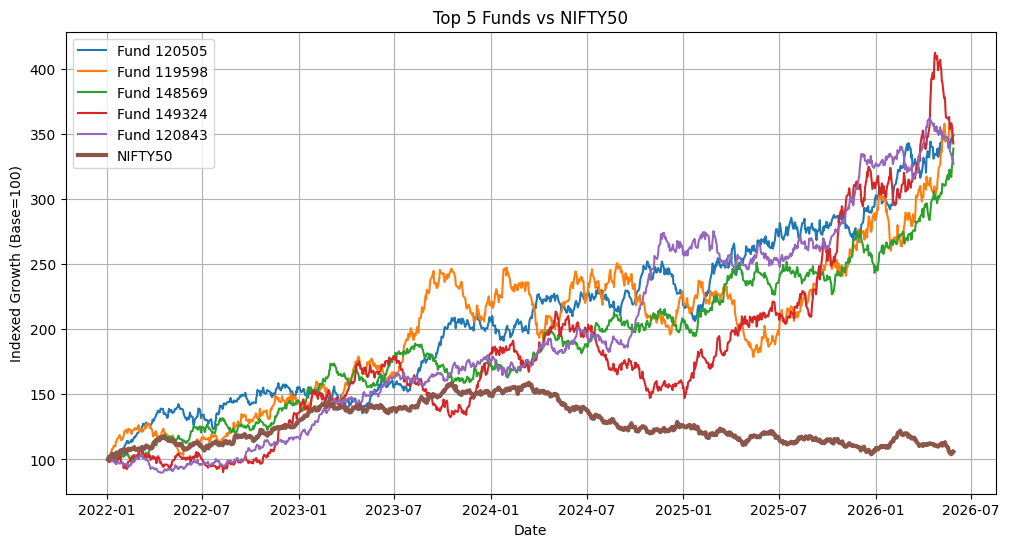

In [30]:
import matplotlib.pyplot as plt



top_funds = scorecard_df.head(5)["amfi_code"].tolist()

plt.figure(figsize=(12,6))

for fund in top_funds:
    fund_data = nav_df[nav_df["amfi_code"] == fund]

    plt.plot(
        fund_data["date"],
        fund_data["nav"] / fund_data["nav"].iloc[0] * 100,
        label=f"Fund {fund}"
    )


nifty50_data = benchmark_df[benchmark_df["index_name"] == "NIFTY50"]

plt.plot(
    nifty50_data["date"],
    nifty50_data["close_value"] / nifty50_data["close_value"].iloc[0] * 100,
    label="NIFTY50",
    linewidth=3
)

plt.title("Top 5 Funds vs NIFTY50")
plt.xlabel("Date")
plt.ylabel("Indexed Growth (Base=100)")
plt.legend()
plt.grid(True)

plt.savefig("../reports/benchmark_comparison.png")
plt.show()

In [31]:
import os
print(os.listdir("../reports"))

['.ipynb_checkpoints', 'alpha_beta.csv', 'benchmark_comparison.png', 'data_dictionary.md', 'fund_scorecard.csv']
